In [1]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

plt.style.use('ggplot')

DATA_PATH = pathlib.Path().cwd().parent / "data"

# Linear Regression

Linear regression (LR) is a powerful tool in science due to its interpretability and computational efficiency. Although we have many powerful tools nowadays, we still actively use linear models for data analysis. In this section, I will show how to fit linear regression in Python and interpret the results.

## Bivariate Linear Regression

Response variable refers to the term that we are interested in. It's often shown by the letter $y$ and it is dependent on a predictor (or on a set of predictors) which is usually shown by $X$. We will focus on a single predictor case in this subsection. The regression equation:

$\hat{y} = a + bx$

where $\hat{y}$ refers to the model's estimation of $y$.

Since the response variable $y$ cannot fully be explained by the model, we have to add an error term to represent the real value of $y$.

$y = a + bx + ϵ$

$ϵ\sim N(0,\sigma^2)$

As you can see, one of the assumptions of linear regression is that the residuals (errors) are normally distributed. Other assumptions are:

* The errors are independent of each other.
* The errors have constant variance.
* Response variable and predictors are linearly correlated.

Let's look at an example.

**Example**

First Dataset:

$x \sim N(5,1)$

$ϵ \sim N(0,1)$

$y = 2x + ϵ$

Second Dataset:

$x \sim N(5,1)$

$ϵ \sim N(0,1)$

$y = x^4 + ϵ$

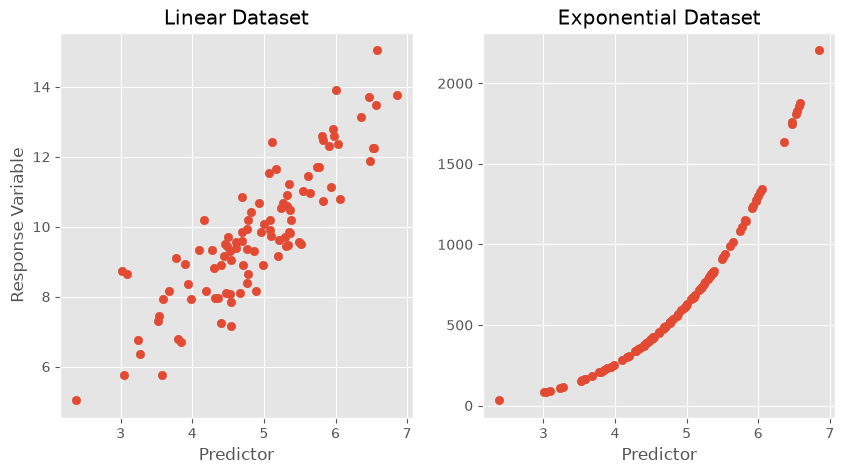

In [2]:
np.random.seed(42)
x = np.random.normal(loc = 5,scale = 1, size = 100)
error = np.random.normal(loc = 0, scale = 1, size = 100)
y = 2*x + error
y2 = x**4 + error
fig,ax = plt.subplots(1,2,figsize = (10,5))
ax[0].scatter(x,y)
ax[0].set_title('Linear Dataset')
ax[0].set_xlabel('Predictor')
ax[0].set_ylabel('Response Variable')

ax[1].scatter(x,y2)
ax[1].set_xlabel('Predictor')
ax[1].set_title('Exponential Dataset')
ax[1].set_ylabel('')
plt.show()

Let's fit a regression model for both of the datasets:

In [3]:
X = sm.add_constant(x)
model0 = sm.OLS(y,X).fit()
model1 = sm.OLS(y2,X).fit()

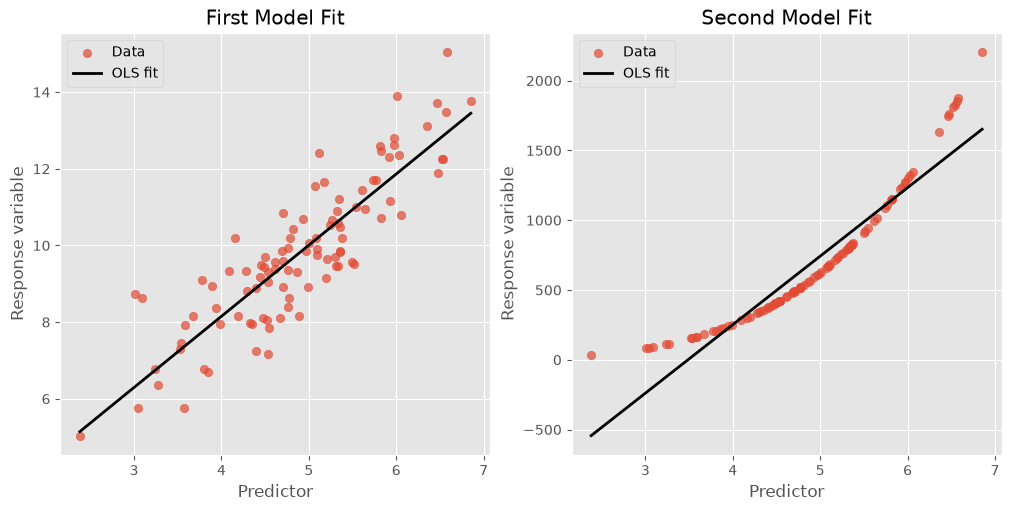

In [4]:
x_sorted = np.sort(x)
X_sorted = sm.add_constant(x_sorted)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

for axis, response, model, title in zip(
    axes,
    [y, y2],
    [model0, model1],
    ["First Model Fit", "Second Model Fit"],
):
    axis.scatter(x, response, alpha=0.7, label="Data")
    axis.plot(x_sorted, model.predict(X_sorted), color="black", linewidth=2, label="OLS fit")
    axis.set_title(title)
    axis.set_xlabel("Predictor")
    axis.set_ylabel("Response variable")
    axis.legend()

plt.show()

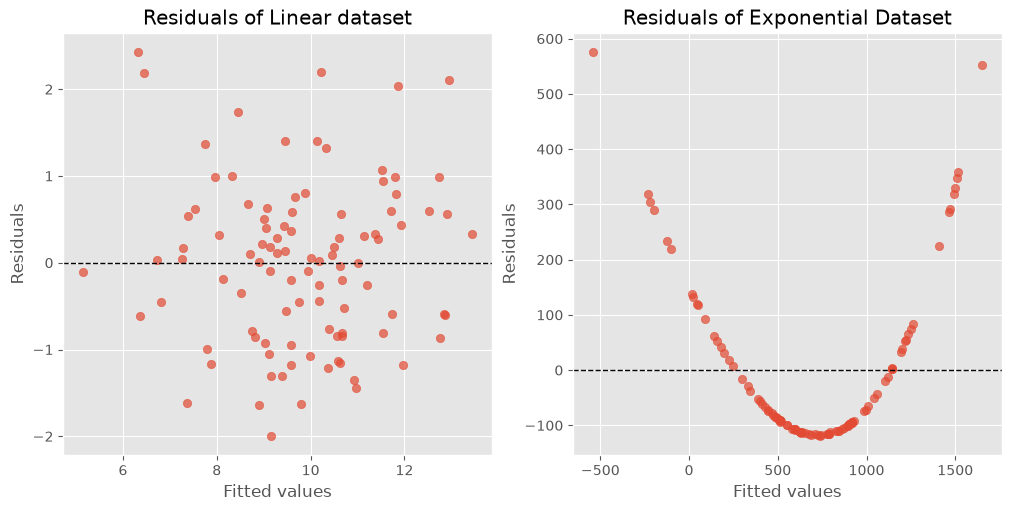

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

for axis, (model, title) in zip(
    axes, [(model0, "Linear dataset"), (model1, "Exponential Dataset")]
):
    fitted = model.fittedvalues
    residuals = model.resid

    axis.scatter(fitted, residuals, alpha=0.7)
    axis.axhline(0, color="black", linestyle="--", linewidth=1)
    axis.set_title(f"Residuals of {title}")
    axis.set_xlabel("Fitted values")
    axis.set_ylabel("Residuals")

plt.show()

The second model violates the linearity assumption. Hence, using second model for both prediction and inference is not logical.

On the other hand, we can use the first model for these purposes.

In [6]:
model = sm.OLS(y,sm.add_constant(x)).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     312.2
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           3.14e-32
Time:                        15:45:17   Log-Likelihood:                -135.71
No. Observations:                 100   AIC:                             275.4
Df Residuals:                      98   BIC:                             280.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7237      0.523      1.383      0.1

The first model fit the data with the following equation:

$\hat{y} = 0.72 + 1.85x$

Not only that, it gave us further information.

* First, the p-value of the intercept is greater than the critical p-value for 95% confidence (0.05). This means that the model is not certain whether the intercept is different from zero. On the other hand, the LR model is much more confident about the slope coefficient. These results should make sense, since we created the data synthetically and know the true parameters.

* $R^2$ is a metric that indicates the proportion of variance in the data explained by the model. Adjusted $R^2$ is similar but penalizes $R^2$ to discourage unnecessary predictor usage (a simpler model is always better if performance is the same). The adjusted $R^2$ and $R^2$ are similar in this case because we used only one predictor to model the response variable.

## Multivariate Linear Regression

When there is more than one predictor, the regression equation is expressed using matrices. Since we are using matrices anyway, we can fold the intercept into them as well.

$\hat{y} = X\hat{\beta}$

$ϵ\sim N(0,\sigma^2)$

The least squares solution for this model is computed analytically as:

$\hat{β} = (X^TX)^{-1}(X^Ty)$



In [7]:
np.random.seed(42)
x = np.random.normal(loc = 5,scale = 1, size = 100)
error = np.random.normal(loc = 0, scale = 1, size = 100)
y = 2*x + error

def OLS_LR(y,X):
    return np.linalg.inv(X.T@X)@X.T@y

beta_manual = OLS_LR(y,sm.add_constant(x))
beta_statsmodels = sm.OLS(y,sm.add_constant(x)).fit().params
print("Manual LR parameters:", beta_manual)
print("Statsmodels LR parameters:", beta_statsmodels)

Manual LR parameters: [0.72371363 1.85674284]
Statsmodels LR parameters: [0.72371363 1.85674284]


Let's see an example.

In [8]:
np.random.seed(42)
x1 = np.random.normal(loc = 5,scale = 1, size = 100)
x2 = np.random.normal(loc = 7,scale = 1, size = 100)
error = np.random.normal(loc = 0, scale = 1, size = 100)
y = 2*x1 + 3*x2 + error

X = np.column_stack((x1,x2))
model = sm.OLS(y,sm.add_constant(X)).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     455.3
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           4.99e-50
Time:                        15:45:17   Log-Likelihood:                -147.62
No. Observations:                 100   AIC:                             301.2
Df Residuals:                      97   BIC:                             309.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9559      1.064     -0.899      0.3

This time the model equation is:

$\hat{y} = -0.95 + 2.22x_1 + 2.98x_2$

The results show that while the coefficients are statistically significant, the intercept is not.

Let's focus on the parameters. What do they refer to?

When the predictors are **independent** (scatterplots, variance influence factors, and Pearson correlations can be used to verify this), each coefficient shows the *relative effect* of predictor $x_i$ on the response variable $y$. For example, each unit increase in $x_1$ results in a 2.22 increase in $y$.

Relative effect is a good starting point, but it is not sufficient on its own. We also need to consider the effect as a whole. This is called *absolute effect*. The absolute and relative effects are the same in linear regression. However, when we build GLMs, these two can differ significantly.
